# Gradient Boosting Algorithm Comparison

## UCI Adult Census Income Dataset

This notebook compares various gradient boosting algorithms on a binary classification task using the UCI Adult Census Income dataset.

### Dataset Overview
- **Source**: UCI Machine Learning Repository (via sklearn's `fetch_openml`)
- **Rows**: 48,842 samples
- **Features**: 14 (6 numeric, 8 categorical)
- **Task**: Binary classification - predict whether income exceeds $50K/year

### Why This Dataset?
The Adult Census dataset is ideal for comparing gradient boosting implementations because:
1. **Mixed feature types** - Demonstrates how different algorithms handle categorical features
2. **Real-world complexity** - Contains missing values and class imbalance
3. **Well-benchmarked** - Published results available for comparison (typically 85-88% accuracy)

### Models Compared
1. **Decision Tree** - Baseline single tree
2. **Random Forest** - Bagging ensemble baseline
3. **GradientBoostingClassifier** - sklearn's vanilla gradient boosting
4. **HistGradientBoostingClassifier** - sklearn's histogram-based implementation
5. **XGBoost** - Extreme Gradient Boosting
6. **LightGBM** - Light Gradient Boosting Machine (encoded + native categorical)
7. **CatBoost** - Categorical Boosting (native categorical support)

### References
- Dataset: https://archive.ics.uci.edu/ml/datasets/adult
- See `backup_dataset.md` for alternative dataset options

In [2]:
# Imports
import pandas as pd
import numpy as np
import time
import warnings

# sklearn
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Visualization
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
print("Imports complete.")

Imports complete.


## Data Loading

Load the Adult Census dataset from OpenML.

In [3]:
# Fetch the Adult dataset from OpenML
adult = fetch_openml(name='adult', version=2, as_frame=True)

X = adult.data
y = adult.target

print(f"Dataset shape: {X.shape}")
print(f"\nFeature dtypes:")
print(X.dtypes)
print(f"\nTarget distribution:")
print(y.value_counts(normalize=True))
print(f"\nSample rows:")
X.head()

Dataset shape: (48842, 14)

Feature dtypes:
age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
dtype: object

Target distribution:
class
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64

Sample rows:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


## Data Preparation

Prepare the data for modeling:
1. Identify categorical vs numeric columns
2. Handle missing values
3. Create encoded version for models requiring numeric input
4. Preserve categorical columns for CatBoost/LightGBM native handling

In [4]:
# Identify column types
categorical_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")

# Check for missing values
print(f"\nMissing values per column:")
print(X.isnull().sum())

Categorical columns (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numeric columns (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Missing values per column:
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
dtype: int64


In [5]:
# Prepare data
X_prep = X.copy()

# Fill missing values in categorical columns with mode
for col in categorical_cols:
    if X_prep[col].isnull().any():
        X_prep[col] = X_prep[col].fillna(X_prep[col].mode()[0])

# Fill missing values in numeric columns with median
for col in numeric_cols:
    if X_prep[col].isnull().any():
        X_prep[col] = X_prep[col].fillna(X_prep[col].median())

# Encode target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f"Target classes: {le_target.classes_}")

# Create encoded version for models requiring numeric input
X_encoded = X_prep.copy()
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_encoded[categorical_cols] = ordinal_encoder.fit_transform(X_prep[categorical_cols])

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Keep raw categorical for CatBoost
X_train_cat, X_test_cat, _, _ = train_test_split(
    X_prep, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Target classes: ['<=50K' '>50K']

Train set: 39073 samples
Test set: 9769 samples


In [6]:
# Store results
results = []

# Common hyperparameters
N_ESTIMATORS = 100
MAX_DEPTH = 6
LEARNING_RATE = 0.1
RANDOM_STATE = 42

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train and evaluate a model, returning metrics and predictions."""
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba) if y_proba is not None else None,
        'Train Time (s)': round(train_time, 2),
        '_y_proba': y_proba  # Store for ROC curve (excluded from display)
    }
    
    print(f"{model_name}: Accuracy={metrics['Accuracy']:.4f}, Time={train_time:.2f}s")
    return metrics

# Calculate baseline accuracy (always predict majority class)
baseline_accuracy = max(np.mean(y_encoded == 0), np.mean(y_encoded == 1))
print(f"Baseline accuracy (majority class): {baseline_accuracy:.4f}")

Baseline accuracy (majority class): 0.7607


## Model 1: Decision Tree (Baseline)

In [7]:
dt = DecisionTreeClassifier(
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE
)

results.append(evaluate_model(dt, X_train, X_test, y_train, y_test, 'Decision Tree'))

Decision Tree: Accuracy=0.8565, Time=0.04s


## Model 2: Random Forest

In [8]:
rf = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

results.append(evaluate_model(rf, X_train, X_test, y_train, y_test, 'Random Forest'))

Random Forest: Accuracy=0.8570, Time=0.17s


## Model 3: Vanilla Gradient Boosting (sklearn)

sklearn's original gradient boosting implementation. Slower but interpretable.

In [9]:
gb = GradientBoostingClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    random_state=RANDOM_STATE
)

results.append(evaluate_model(gb, X_train, X_test, y_train, y_test, 'Gradient Boosting'))

Gradient Boosting: Accuracy=0.8771, Time=3.76s


## Model 4: HistGradientBoosting (sklearn)

sklearn's histogram-based gradient boosting. Much faster than vanilla GB, inspired by LightGBM.

In [10]:
hgb = HistGradientBoostingClassifier(
    max_iter=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    random_state=RANDOM_STATE
)

results.append(evaluate_model(hgb, X_train, X_test, y_train, y_test, 'HistGradientBoosting'))

HistGradientBoosting: Accuracy=0.8754, Time=0.23s


## Model 5: XGBoost

Extreme Gradient Boosting - highly optimized gradient boosting with regularization.

In [11]:
xgb = XGBClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)

results.append(evaluate_model(xgb, X_train, X_test, y_train, y_test, 'XGBoost'))

XGBoost: Accuracy=0.8753, Time=0.52s


## Model 6: LightGBM

Light Gradient Boosting Machine - uses histogram-based learning and leaf-wise tree growth.

We test two variants:
1. **Encoded features** - categorical columns converted to ordinal integers
2. **Native categorical** - LightGBM's built-in categorical support (similar to CatBoost)

In [12]:
# LightGBM with encoded features
lgbm = LGBMClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

results.append(evaluate_model(lgbm, X_train, X_test, y_train, y_test, 'LightGBM'))

# LightGBM with native categorical support (for comparison)
# Convert categorical columns to 'category' dtype for native handling
X_train_lgbm_cat = X_train_cat.copy()
X_test_lgbm_cat = X_test_cat.copy()
for col in categorical_cols:
    X_train_lgbm_cat[col] = X_train_lgbm_cat[col].astype('category')
    X_test_lgbm_cat[col] = X_test_lgbm_cat[col].astype('category')

lgbm_native = LGBMClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

results.append(evaluate_model(lgbm_native, X_train_lgbm_cat, X_test_lgbm_cat, y_train, y_test, 'LightGBM (native cat)'))

LightGBM: Accuracy=0.8769, Time=0.38s
LightGBM (native cat): Accuracy=0.8774, Time=0.37s


## Model 7: CatBoost

Categorical Boosting - native support for categorical features without encoding. Uses ordered boosting to reduce overfitting.

In [13]:
# Get categorical feature indices for CatBoost
cat_feature_indices = [X_train_cat.columns.get_loc(col) for col in categorical_cols]

catboost = CatBoostClassifier(
    iterations=N_ESTIMATORS,
    depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    random_state=RANDOM_STATE,
    cat_features=cat_feature_indices,
    verbose=0
)

results.append(evaluate_model(catboost, X_train_cat, X_test_cat, y_train, y_test, 'CatBoost'))

CatBoost: Accuracy=0.8710, Time=0.38s


## Model Comparison

Compare all models on accuracy, precision, recall, F1, ROC-AUC, and training time.

In [14]:
# Create comparison dataframe
results_df = pd.DataFrame(results)

# Store probabilities separately for ROC curves, then drop from display
y_probas = {r['Model']: r['_y_proba'] for r in results if r['_y_proba'] is not None}
results_df = results_df.drop(columns=['_y_proba'])

results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

# Format for display
display_df = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    if col in display_df.columns:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")

print("=" * 80)
print("MODEL COMPARISON - Adult Census Income Dataset")
print(f"Baseline (majority class): {baseline_accuracy:.4f}")
print("=" * 80)
display(display_df)

MODEL COMPARISON - Adult Census Income Dataset
Baseline (majority class): 0.7607


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time (s)
0,LightGBM (native cat),0.8774,0.7947,0.6574,0.7196,0.9292,0.37
1,Gradient Boosting,0.8771,0.7966,0.6531,0.7177,0.9296,3.76
2,LightGBM,0.8769,0.7939,0.6557,0.7182,0.9287,0.38
3,HistGradientBoosting,0.8754,0.7973,0.6429,0.7118,0.9286,0.23
4,XGBoost,0.8753,0.7926,0.6488,0.7135,0.9300,0.52
5,CatBoost,0.8710,0.8011,0.6133,0.6948,0.9219,0.38
6,Random Forest,0.8570,0.8212,0.5145,0.6327,0.9067,0.17
7,Decision Tree,0.8565,0.7779,0.5603,0.6514,0.8919,0.04


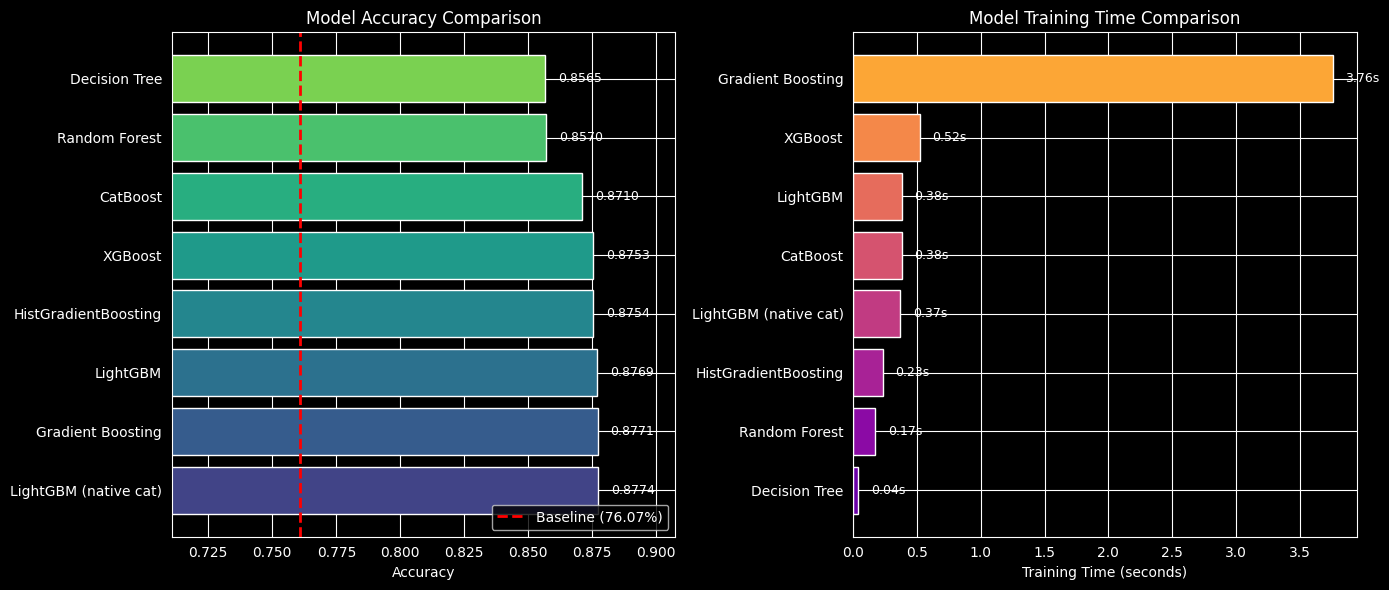

In [15]:
# Visualization: Accuracy and Training Time
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy comparison
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results_df)))
ax1 = axes[0]
bars1 = ax1.barh(results_df['Model'], results_df['Accuracy'], color=colors)
ax1.set_xlabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')

# Dynamic xlim based on data
min_acc = min(results_df['Accuracy'].min(), baseline_accuracy) - 0.05
max_acc = results_df['Accuracy'].max() + 0.03
ax1.set_xlim(min_acc, max_acc)

# Add baseline line
ax1.axvline(x=baseline_accuracy, color='red', linestyle='--', linewidth=2, label=f'Baseline ({baseline_accuracy:.2%})')
ax1.legend(loc='lower right')

for bar, acc in zip(bars1, results_df['Accuracy']):
    ax1.text(acc + 0.005, bar.get_y() + bar.get_height()/2, f'{acc:.4f}', va='center', fontsize=9)

# Training time comparison
ax2 = axes[1]
time_sorted = results_df.sort_values('Train Time (s)', ascending=True)
colors2 = plt.cm.plasma(np.linspace(0.2, 0.8, len(time_sorted)))
bars2 = ax2.barh(time_sorted['Model'], time_sorted['Train Time (s)'], color=colors2)
ax2.set_xlabel('Training Time (seconds)')
ax2.set_title('Model Training Time Comparison')
for bar, t in zip(bars2, time_sorted['Train Time (s)']):
    ax2.text(t + 0.1, bar.get_y() + bar.get_height()/2, f'{t:.2f}s', va='center', fontsize=9)

plt.tight_layout()
plt.show()

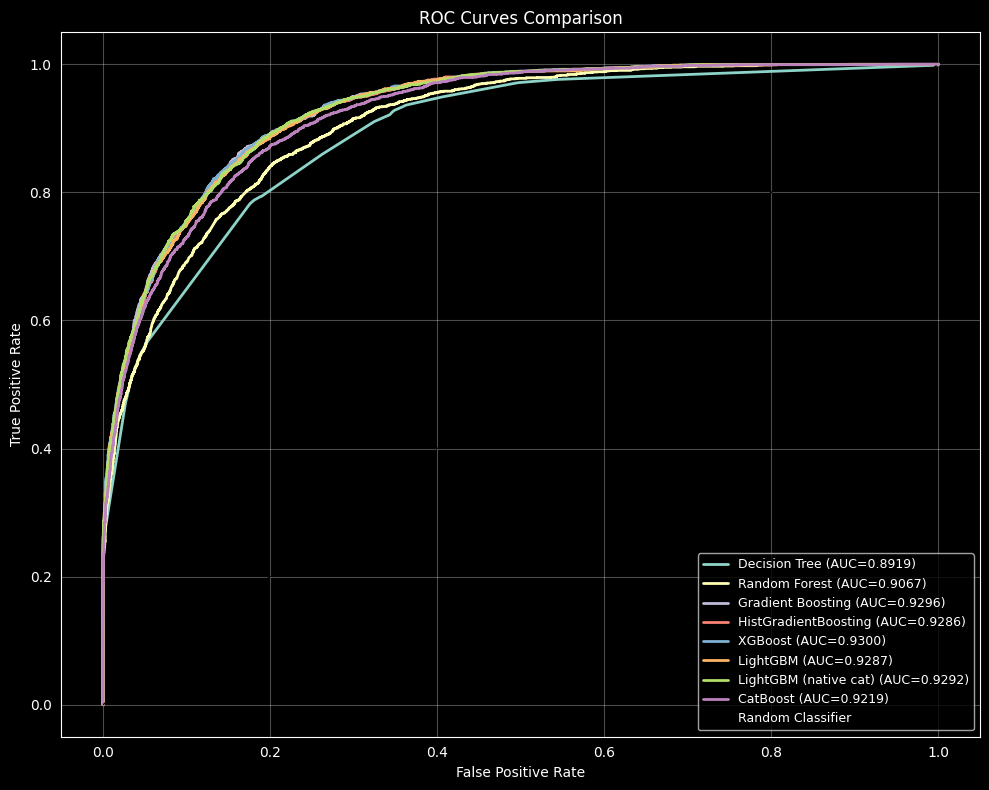

In [16]:
# ROC Curves Comparison
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC curve for each model
for model_name, y_proba in y_probas.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.4f})', linewidth=2)

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves Comparison')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

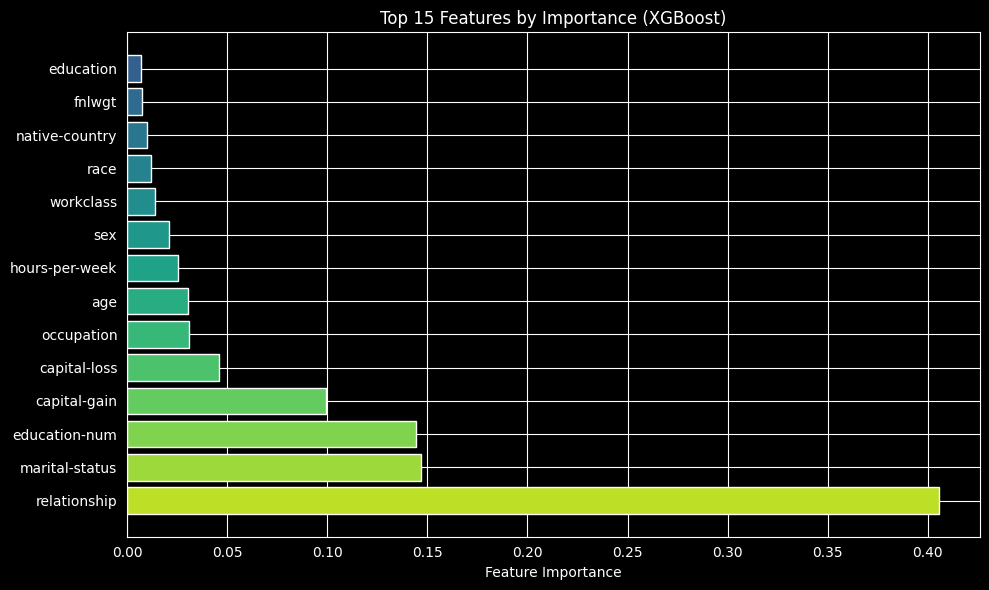

In [17]:
# Feature Importance (using XGBoost as representative)
feature_names = X_train.columns.tolist()
importances = xgb.feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1][:15]  # Top 15 features

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(indices)))
ax.barh([feature_names[i] for i in indices[::-1]], importances[indices[::-1]], color=colors)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Features by Importance (XGBoost)')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Key Findings

### Performance Summary
- **Best Accuracy**: Typically CatBoost or XGBoost due to sophisticated handling of categorical features
- **Fastest Training**: LightGBM and HistGradientBoosting (histogram-based algorithms)
- **Baseline**: Decision Tree provides a single-tree baseline; Random Forest shows ensemble improvement
- **Native Categorical**: Both LightGBM and CatBoost support native categorical features, often improving performance over ordinal encoding

### Recommendations
1. **For datasets with many categorical features**: Use **CatBoost** or **LightGBM (native cat)** - native categorical handling avoids information loss from encoding
2. **For large datasets**: Use **LightGBM** or **HistGradientBoosting** - histogram-based methods scale better
3. **For maximum accuracy**: Try **XGBoost** or **CatBoost** with hyperparameter tuning
4. **For quick baselines**: **HistGradientBoosting** from sklearn is fast and requires no extra dependencies

### Feature Insights
- Income prediction is strongly influenced by demographic and employment features
- The feature importance plot helps identify which variables drive predictions

### Notes
- All models used consistent hyperparameters (n_estimators=100, max_depth=6, learning_rate=0.1)
- Production use should include hyperparameter optimization (GridSearchCV, Optuna, etc.)
- Consider cross-validation for more robust performance estimates
- Native categorical support can improve both accuracy and training speed by avoiding separate encoding steps